In [47]:
from collections.abc import Mapping
from pathlib import Path
import json
import math
import sys
import random

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import optim
from torchvision import transforms
import matplotlib.pyplot as plt
from IPython.display import Image as DisplayImage, display

NOTEBOOK_CWD = Path.cwd().resolve()
PROJECT_ROOT = NOTEBOOK_CWD if (NOTEBOOK_CWD / "src").exists() else NOTEBOOK_CWD.parent
for import_root in (PROJECT_ROOT, PROJECT_ROOT / "src"):
    if str(import_root) not in sys.path:
        sys.path.insert(0, str(import_root))

from cody_jepa.data import (
    HealthGaitLoaderConfig,
    build_healthgait_datasets_from_config,
    build_healthgait_loaders_from_config,
    find_repo_root,
    healthgait_manifest_path,
    preview_manifest,
    summarize_healthgait_manifest,
    write_healthgait_metadata_summary,
)


CONFIG = {
    "seed": 0,

    "batch_size": 8,
    "num_epochs": 5,
    "steps": 1500,
    "lr": 1e-4,
    "ema_tau": 0.9995,
    
    "num_frames": 16,
    "img_size": 72,
    "patch_size": 12,
    "tubelet_size": 2,
    "in_channels": 1,
    "num_tokens": 288,
    "min_context_tokens": 8,
    "mask_aspect_ratio": (0.75, 1.5),

    "embed_dim": 128,
    "hidden_dim": 512,
    "pred_dim": 256,
    "pred_depth": 2,
    "num_heads": 4,
    "num_layers": 4,
    "dropout": 0.1,
}

MODEL_ARCHITECTURE = "cody-jepa-vjepa-tubelet-v1"

In [48]:
REPO_ROOT = find_repo_root()
MANIFEST_CSV = healthgait_manifest_path(REPO_ROOT)
LOADER_CONFIG = HealthGaitLoaderConfig(
    manifest_csv=MANIFEST_CSV,
    repo_root=REPO_ROOT,
    split="train",
    clip_length=CONFIG["num_frames"],
    image_size=(CONFIG["img_size"], CONFIG["img_size"]),
    batch_size=CONFIG["batch_size"],
    seed=CONFIG["seed"],
    num_workers=8,
    pin_memory=True
)

print(f"repo root: {REPO_ROOT}")
print(f"manifest:  {MANIFEST_CSV}")
print(f"exists:    {MANIFEST_CSV.exists()}")
print("loader config:")
print(json.dumps(LOADER_CONFIG.as_dict(), indent=2, sort_keys=True))

repo root: /Users/theodoremui/dev/cody-jepa
manifest:  /Users/theodoremui/dev/cody-jepa/data/healthgait/manifests/silhouette_subject_split_seed0.csv
exists:    True
loader config:
{
  "batch_size": 8,
  "channels": 1,
  "clip_length": 16,
  "image_size": [
    72,
    72
  ],
  "manifest_csv": "/Users/theodoremui/dev/cody-jepa/data/healthgait/manifests/silhouette_subject_split_seed0.csv",
  "num_workers": 8,
  "pin_memory": true,
  "repo_root": "/Users/theodoremui/dev/cody-jepa",
  "seed": 0,
  "split": "train",
  "strict_validation": true,
  "window_policy": "train_random_val_center"
}


In [49]:
diagnostic_epoch = 0

train_ds, val_ds = build_healthgait_datasets_from_config(LOADER_CONFIG)
train_ds.set_epoch(diagnostic_epoch)

print(f"train clips: {len(train_ds)}")
print(f"val clips:   {len(val_ds)}")

train clips: 2506
val clips:   624


In [50]:
train_loader, val_loader = build_healthgait_loaders_from_config(LOADER_CONFIG)

In [51]:
MASK_GROUPS = [("short", 8, 0.15), ("long", 2, 0.7)]
_DEFAULT_MASK_RNG = random.Random(CONFIG.get("seed", 0))


def _block_size(spatial_grid, scale, aspect_ratio):
    spatial_area = max(1, int(spatial_grid * spatial_grid * scale))
    height = min(spatial_grid, max(1, round(math.sqrt(spatial_area * aspect_ratio))))
    width = min(spatial_grid, max(1, round(math.sqrt(spatial_area / aspect_ratio))))
    return height, width


def _sample_spatial_tubes(n_blocks, height, width, spatial_grid, rng, min_visible_cells):
    if height * width > spatial_grid * spatial_grid - min_visible_cells:
        raise ValueError(
            f"a {height}x{width} block cannot leave {min_visible_cells} visible spatial cells "
            f"on a {spatial_grid}x{spatial_grid} grid"
        )

    all_cells = set(range(spatial_grid * spatial_grid))
    for _ in range(1024):
        masked = set()
        for _ in range(n_blocks):
            top = rng.randrange(spatial_grid - height + 1)
            left = rng.randrange(spatial_grid - width + 1)
            masked.update(
                row * spatial_grid + col
                for row in range(top, top + height)
                for col in range(left, left + width)
            )
        visible = all_cells - masked
        if len(visible) >= min_visible_cells:
            return masked, visible

    # A valid one-block placement is also a valid n-block union when all blocks overlap.
    top = rng.randrange(spatial_grid - height + 1)
    left = rng.randrange(spatial_grid - width + 1)
    masked = {
        row * spatial_grid + col
        for row in range(top, top + height)
        for col in range(left, left + width)
    }
    return masked, all_cells - masked


def _expand_tubes(spatial_cells, temporal_grid, spatial_grid):
    cells_per_step = spatial_grid * spatial_grid
    return [
        time_index * cells_per_step + cell
        for time_index in range(temporal_grid)
        for cell in spatial_cells
    ]


def multiblock_mask(cfg, batch_size=None, rng=None, device=None):
    batch_size = int(cfg["batch_size"] if batch_size is None else batch_size)
    num_frames = int(cfg["num_frames"])
    image_size = int(cfg["img_size"])
    patch_size = int(cfg["patch_size"])
    tubelet_size = int(cfg["tubelet_size"])
    min_context_tokens = int(cfg.get("min_context_tokens", 8))
    aspect_ratio_range = tuple(cfg.get("mask_aspect_ratio", (0.75, 1.5)))

    if batch_size <= 0:
        raise ValueError(f"batch_size must be positive, got {batch_size}")
    if tubelet_size <= 0 or num_frames % tubelet_size != 0:
        raise ValueError("tubelet_size must be positive and divide num_frames")
    if patch_size <= 0 or image_size % patch_size != 0:
        raise ValueError("patch_size must be positive and divide img_size")
    if min_context_tokens <= 0:
        raise ValueError("min_context_tokens must be positive")
    if len(aspect_ratio_range) != 2 or not 0 < aspect_ratio_range[0] <= aspect_ratio_range[1]:
        raise ValueError("mask_aspect_ratio must be a positive (min, max) pair")

    temporal_grid = num_frames // tubelet_size
    spatial_grid = image_size // patch_size
    num_tokens = temporal_grid * spatial_grid * spatial_grid
    if int(cfg["num_tokens"]) != num_tokens:
        raise ValueError(
            f"num_tokens={cfg['num_tokens']} but tubelet geometry produces {num_tokens}"
        )

    rng = _DEFAULT_MASK_RNG if rng is None else rng
    min_visible_cells = max(1, math.ceil(min_context_tokens / temporal_grid))
    groups = []
    for label, n_blocks, scale in MASK_GROUPS:
        height, width = _block_size(
            spatial_grid, scale, rng.uniform(*aspect_ratio_range)
        )
        context_spatial = []
        target_spatial = []
        for _ in range(batch_size):
            masked, visible = _sample_spatial_tubes(
                n_blocks, height, width, spatial_grid, rng, min_visible_cells
            )
            context_spatial.append(sorted(visible))
            target_spatial.append(sorted(masked))

        context_cells = min(map(len, context_spatial))
        target_cells = min(map(len, target_spatial))
        # Trim whole spatial cells before temporal expansion so every mask stays tubular.
        context = [
            _expand_tubes(sorted(rng.sample(cells, context_cells)), temporal_grid, spatial_grid)
            for cells in context_spatial
        ]
        target = [
            _expand_tubes(sorted(rng.sample(cells, target_cells)), temporal_grid, spatial_grid)
            for cells in target_spatial
        ]
        groups.append({
            "label": label,
            "n_blocks": n_blocks,
            "block_hw": (height, width),
            "requested_scale": scale,
            "realized_block_scale": height * width / (spatial_grid * spatial_grid),
            "ctx": torch.tensor(context, dtype=torch.long, device=device),
            "pred": torch.tensor(target, dtype=torch.long, device=device),
        })
    return groups


mask_groups = multiblock_mask(CONFIG)
for group in mask_groups:
    print(
        f"{group['label']:>5} | block={group['block_hw']} x {group['n_blocks']} "
        f"({group['realized_block_scale']:.1%} vs {group['requested_scale']:.0%}) | "
        f"context={tuple(group['ctx'].shape)} | target={tuple(group['pred'].shape)}"
    )

short | block=(3, 2) x 8 (16.7% vs 15%) | context=(8, 56) | target=(8, 136)
 long | block=(5, 5) x 2 (69.4% vs 70%) | context=(8, 16) | target=(8, 200)


In [52]:
class AttentionBlock(nn.Module):

    def __init__(self, embed_dim, hidden_dim, num_heads, dropout=0.1):
        super().__init__()

        self.layer_norm_1 = nn.LayerNorm(embed_dim)
        self.attn = nn.MultiheadAttention(
            embed_dim, num_heads, dropout=dropout, batch_first=True
        )
        self.layer_norm_2 = nn.LayerNorm(embed_dim)
        self.linear = nn.Sequential(
            nn.Linear(embed_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, embed_dim),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        residual = self.layer_norm_1(x)
        x = x + self.attn(residual, residual, residual, need_weights=False)[0]
        return x + self.linear(self.layer_norm_2(x))


In [53]:
def image_to_patch(x, patch_size, flatten_channels=True, tubelet_size=2):
    if x.ndim != 5:
        raise ValueError(f"expected video shaped [B, T, C, H, W], got {tuple(x.shape)}")

    B, T, C, H, W = x.shape
    if tubelet_size <= 0 or T % tubelet_size != 0:
        raise ValueError(f"T={T} must be divisible by tubelet_size={tubelet_size}")
    if patch_size <= 0 or H % patch_size != 0 or W % patch_size != 0:
        raise ValueError(f"image size {(H, W)} must be divisible by patch_size={patch_size}")

    temporal_grid = T // tubelet_size
    height_grid = H // patch_size
    width_grid = W // patch_size
    x = x.reshape(
        B, temporal_grid, tubelet_size, C,
        height_grid, patch_size, width_grid, patch_size,
    )
    x = x.permute(0, 1, 4, 6, 3, 2, 5, 7)
    x = x.flatten(1, 3)  # [B, T' * H' * W', C, tubelet, p_H, p_W]
    if flatten_channels:
        x = x.flatten(2)  # [B, T' * H' * W', C * tubelet * p_H * p_W]
    return x


def _sincos_1d(coordinates, embed_dim):
    omega = torch.arange(embed_dim // 2, dtype=torch.float32)
    omega = 1.0 / (10000 ** (omega / (embed_dim / 2)))
    angles = coordinates.reshape(-1, 1).float() * omega.reshape(1, -1)
    return torch.cat([angles.sin(), angles.cos()], dim=1)


def sincos_3d_position_embedding(temporal_grid, height_grid, width_grid, embed_dim):
    if embed_dim <= 0 or embed_dim % 8 != 0:
        raise ValueError("3D position embed_dim must be positive and divisible by 8")
    temporal_dim = embed_dim // 2
    spatial_dim = embed_dim // 4
    time, height, width = torch.meshgrid(
        torch.arange(temporal_grid),
        torch.arange(height_grid),
        torch.arange(width_grid),
        indexing="ij",
    )
    embedding = torch.cat([
        _sincos_1d(time, temporal_dim),
        _sincos_1d(height, spatial_dim),
        _sincos_1d(width, spatial_dim),
    ], dim=1)
    return embedding.unsqueeze(0)


class VisionTransformer(nn.Module):

    def __init__(self, embed_dim, hidden_dim, num_heads, num_layers, patch_size,
                 tubelet_size, num_frames, image_size, in_channels, dropout=0.1):
        super().__init__()
        self.patch_size = int(patch_size)
        self.tubelet_size = int(tubelet_size)
        self.num_frames = int(num_frames)
        self.image_size = int(image_size)
        self.in_channels = int(in_channels)
        if self.tubelet_size <= 0 or self.num_frames % self.tubelet_size != 0:
            raise ValueError("tubelet_size must be positive and divide num_frames")
        if self.patch_size <= 0 or self.image_size % self.patch_size != 0:
            raise ValueError("patch_size must be positive and divide image_size")
        if self.in_channels <= 0:
            raise ValueError("in_channels must be positive")
        if not 0.0 <= dropout < 1.0:
            raise ValueError("dropout must be in [0, 1)")
        self.grid_size = (
            self.num_frames // self.tubelet_size,
            self.image_size // self.patch_size,
            self.image_size // self.patch_size,
        )
        self.num_patches = math.prod(self.grid_size)

        self.patch_embed = nn.Conv3d(
            in_channels=self.in_channels,
            out_channels=embed_dim,
            kernel_size=(self.tubelet_size, self.patch_size, self.patch_size),
            stride=(self.tubelet_size, self.patch_size, self.patch_size),
        )
        nn.init.trunc_normal_(self.patch_embed.weight, std=0.02)
        nn.init.zeros_(self.patch_embed.bias)
        self.register_buffer(
            "pos_embedding",
            sincos_3d_position_embedding(*self.grid_size, embed_dim),
        )
        self.dropout = nn.Dropout(dropout)
        self.transformer = nn.Sequential(*[
            AttentionBlock(embed_dim, hidden_dim, num_heads, dropout)
            for _ in range(num_layers)
        ])
        self.output_layer = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Linear(embed_dim, embed_dim),
        )

    @staticmethod
    def _batched_indices(indices, batch_size, num_tokens, device):
        indices = torch.as_tensor(indices, dtype=torch.long, device=device)
        if indices.ndim == 1:
            indices = indices.unsqueeze(0).expand(batch_size, -1)
        if indices.ndim != 2 or indices.size(0) != batch_size:
            raise ValueError(
                f"token indices must have shape [B, K] or [K], got {tuple(indices.shape)}"
            )
        if indices.numel() and (indices.min() < 0 or indices.max() >= num_tokens):
            raise IndexError(f"token indices must be in [0, {num_tokens})")
        return indices

    def forward(self, video, token_indices=None):
        if video.ndim != 5:
            raise ValueError(
                f"expected video shaped [B, T, C, H, W], got {tuple(video.shape)}"
            )

        B, T, C, H, W = video.shape
        expected = (self.num_frames, self.in_channels, self.image_size, self.image_size)
        if (T, C, H, W) != expected:
            raise ValueError(
                f"encoder configured for [T, C, H, W]={expected}, got {(T, C, H, W)}"
            )

        x = self.patch_embed(video.permute(0, 2, 1, 3, 4).contiguous())
        if tuple(x.shape[2:]) != self.grid_size:
            raise RuntimeError(
                f"Conv3d produced grid {tuple(x.shape[2:])}, expected {self.grid_size}"
            )
        # Conv3d flattens its [T', H', W'] grid in time-major row-major order.
        x = x.flatten(2).transpose(1, 2)
        pos = self.pos_embedding.expand(B, -1, -1)
        if token_indices is not None:
            token_indices = self._batched_indices(
                token_indices, B, self.num_patches, video.device
            )
            gather_idx = token_indices.unsqueeze(-1).expand(-1, -1, x.size(-1))
            x = torch.gather(x, 1, gather_idx)
            pos = torch.gather(pos, 1, gather_idx)

        x = self.dropout(x + pos)
        x = self.transformer(x)
        return self.output_layer(x)  # [B, N, D] or [B, K, D] when indexed

In [54]:
class Predictor(nn.Module):

    def __init__(self, dim, pred_dim, depth, n_heads, grid_size,
                 num_mask_tokens=2, dropout=0.1):
        super().__init__()
        if len(grid_size) != 3 or any(int(size) <= 0 for size in grid_size):
            raise ValueError("grid_size must contain three positive dimensions")
        if num_mask_tokens <= 0:
            raise ValueError("num_mask_tokens must be positive")
        self.n_tokens = math.prod(grid_size)
        self.embed = nn.Linear(dim, pred_dim)
        self.register_buffer(
            "pos", sincos_3d_position_embedding(*grid_size, pred_dim)
        )
        self.mask_tokens = nn.ParameterList([
            nn.Parameter(torch.zeros(1, 1, pred_dim))
            for _ in range(num_mask_tokens)
        ])
        for mask_token in self.mask_tokens:
            nn.init.trunc_normal_(mask_token, std=0.02)
        self.blocks = nn.ModuleList([
            AttentionBlock(pred_dim, pred_dim * 4, n_heads, dropout)
            for _ in range(depth)
        ])
        self.norm = nn.LayerNorm(pred_dim)
        self.out = nn.Linear(pred_dim, dim)

    def _position_tokens(self, indices, batch_size):
        indices = VisionTransformer._batched_indices(
            indices, batch_size, self.n_tokens, self.pos.device
        )
        pos = self.pos.expand(batch_size, -1, -1)
        gather_idx = indices.unsqueeze(-1).expand(-1, -1, pos.size(-1))
        return torch.gather(pos, 1, gather_idx), indices

    def forward(self, ctx_tokens, ctx_idx, tgt_idx, mask_index=0):
        if ctx_tokens.ndim != 3:
            raise ValueError(f"ctx_tokens must be [B, K, D], got {tuple(ctx_tokens.shape)}")

        B = ctx_tokens.size(0)
        ctx_pos, ctx_idx = self._position_tokens(ctx_idx, B)
        tgt_pos, tgt_idx = self._position_tokens(tgt_idx, B)
        if ctx_tokens.size(1) != ctx_idx.size(1):
            raise ValueError("ctx_tokens and ctx_idx must contain the same number of tokens")
        if tgt_idx.size(1) == 0:
            raise ValueError("tgt_idx must contain at least one target token")
        if not 0 <= mask_index < len(self.mask_tokens):
            raise IndexError(f"mask_index must be in [0, {len(self.mask_tokens)})")

        context = self.embed(ctx_tokens) + ctx_pos
        masked = self.mask_tokens[mask_index].expand(B, tgt_idx.size(1), -1) + tgt_pos
        h = torch.cat([context, masked], dim=1)
        for block in self.blocks:
            h = block(h)
        h = self.norm(h[:, -tgt_idx.size(1):, :])
        return self.out(h)  # [B, M, D]

In [55]:
@torch.no_grad()
def ema_update(target, online, tau):
    if not 0.0 <= tau <= 1.0:
        raise ValueError(f"tau must be in [0, 1], got {tau}")

    target_params = dict(target.named_parameters())
    online_params = dict(online.named_parameters())
    if target_params.keys() != online_params.keys():
        raise ValueError("target and online encoders have different parameter structures")
    for name, target_param in target_params.items():
        target_param.mul_(tau).add_(online_params[name], alpha=1.0 - tau)

    target_buffers = dict(target.named_buffers())
    online_buffers = dict(online.named_buffers())
    if target_buffers.keys() != online_buffers.keys():
        raise ValueError("target and online encoders have different buffer structures")
    for name, target_buffer in target_buffers.items():
        target_buffer.copy_(online_buffers[name])

In [56]:
def video_from_batch(batch, device):
    if not isinstance(batch, Mapping):
        raise TypeError(f"expected a DataLoader mapping, got {type(batch).__name__}")
    if "video" not in batch:
        raise KeyError("DataLoader batch is missing the 'video' field")

    video = batch["video"]
    if not isinstance(video, torch.Tensor):
        raise TypeError(f"batch['video'] must be a tensor, got {type(video).__name__}")
    if video.ndim != 5:
        raise ValueError(f"batch['video'] must be [B, T, C, H, W], got {tuple(video.shape)}")
    return video.to(device, non_blocking=True)

In [57]:
def validate_jepa_config(cfg):
    positive_keys = (
        "num_epochs", "batch_size", "num_frames", "img_size", "patch_size",
        "tubelet_size", "in_channels", "num_tokens", "min_context_tokens",
        "embed_dim", "hidden_dim", "pred_dim", "pred_depth", "num_heads",
        "num_layers", "steps",
    )
    for key in positive_keys:
        if int(cfg[key]) <= 0:
            raise ValueError(f"cfg['{key}'] must be positive")
    if float(cfg["lr"]) <= 0.0:
        raise ValueError("cfg['lr'] must be positive")
    if not 0.0 <= float(cfg.get("dropout", 0.1)) < 1.0:
        raise ValueError("cfg['dropout'] must be in [0, 1)")
    if cfg["img_size"] % cfg["patch_size"] != 0:
        raise ValueError("img_size must be divisible by patch")
    if cfg["num_frames"] % cfg["tubelet_size"] != 0:
        raise ValueError("num_frames must be divisible by tubelet_size")

    temporal_grid = cfg["num_frames"] // cfg["tubelet_size"]
    spatial_grid = cfg["img_size"] // cfg["patch_size"]
    expected_tokens = temporal_grid * spatial_grid ** 2
    if cfg["num_tokens"] != expected_tokens:
        raise ValueError(
            f"num_tokens={cfg['num_tokens']} but frames and patch geometry produce {expected_tokens}"
        )
    if cfg["embed_dim"] % cfg["num_heads"] != 0:
        raise ValueError("embed_dim must be divisible by num_heads")
    if cfg["pred_dim"] % cfg["num_heads"] != 0:
        raise ValueError("pred_dim must be divisible by num_heads")
    if cfg["embed_dim"] % 8 != 0 or cfg["pred_dim"] % 8 != 0:
        raise ValueError("embed_dim and pred_dim must be divisible by 8 for 3D positions")
    if not 0.0 <= cfg["ema_tau"] <= 1.0:
        raise ValueError("ema_tau must be in [0, 1]")
    if cfg["min_context_tokens"] > expected_tokens:
        raise ValueError("min_context_tokens cannot exceed num_tokens")
    groups = multiblock_mask(cfg, batch_size=2)
    if len(groups) != len(MASK_GROUPS):
        raise RuntimeError("mask sampler returned the wrong number of groups")
    for group in groups:
        if group["ctx"].ndim != 2 or group["pred"].ndim != 2:
            raise RuntimeError("mask tensors must be rectangular [B, K] tensors")
        if group["ctx"].size(1) < cfg["min_context_tokens"]:
            raise RuntimeError(f"{group['label']} mask has too few context tokens")
        if group["pred"].size(1) == 0:
            raise RuntimeError(f"{group['label']} mask has no target tokens")
        for context, target in zip(group["ctx"], group["pred"]):
            if context.unique().numel() != context.numel():
                raise RuntimeError(f"{group['label']} context contains duplicate indices")
            if target.unique().numel() != target.numel():
                raise RuntimeError(f"{group['label']} target contains duplicate indices")
            if context.min() < 0 or context.max() >= expected_tokens:
                raise RuntimeError(f"{group['label']} context has out-of-range indices")
            if target.min() < 0 or target.max() >= expected_tokens:
                raise RuntimeError(f"{group['label']} target has out-of-range indices")
            if torch.isin(context, target).any():
                raise RuntimeError(f"{group['label']} context overlaps its target")
            for name, indices in (("context", context), ("target", target)):
                cells = indices.remainder(spatial_grid ** 2)
                unique_cells, counts = cells.unique(return_counts=True)
                if not torch.all(counts == temporal_grid):
                    raise RuntimeError(f"{group['label']} {name} contains a partial tube")
                if indices.numel() != unique_cells.numel() * temporal_grid:
                    raise RuntimeError(f"{group['label']} {name} tube cardinality is invalid")
            max_target_cells = group["n_blocks"] * math.prod(group["block_hw"])
            if target.numel() // temporal_grid > max_target_cells:
                raise RuntimeError(f"{group['label']} target exceeds sampled block capacity")


def gather_tokens(tokens, indices):
    indices = VisionTransformer._batched_indices(
        indices, tokens.size(0), tokens.size(1), tokens.device
    )
    gather_idx = indices.unsqueeze(-1).expand(-1, -1, tokens.size(-1))
    return torch.gather(tokens, 1, gather_idx)


def jepa_step(ctx_enc, tgt_enc, predictor, video, mask_groups):
    with torch.no_grad():
        all_target_tokens = tgt_enc(video)
        all_target_tokens = F.layer_norm(
            all_target_tokens, (all_target_tokens.size(-1),)
        )

    losses = []
    cosines = []
    for mask_index, group in enumerate(mask_groups):
        context_idx = group["ctx"]
        target_idx = group["pred"]
        context_tokens = ctx_enc(video, context_idx)
        target_tokens = gather_tokens(all_target_tokens, target_idx)
        predicted_tokens = predictor(
            context_tokens, context_idx, target_idx, mask_index=mask_index
        )
        losses.append(F.smooth_l1_loss(predicted_tokens, target_tokens))
        cosines.append(
            F.cosine_similarity(predicted_tokens, target_tokens, dim=-1).mean()
        )
    return torch.stack(losses).mean(), torch.stack(cosines).mean()


def train_jepa(cfg, train_loader, val_loader, device=None, resume_state=None):
    validate_jepa_config(cfg)
    seed = int(cfg.get("seed", 0))
    torch.manual_seed(seed)
    loader_generator = getattr(train_loader, "generator", None)
    if isinstance(loader_generator, torch.Generator):
        loader_generator.manual_seed(seed)

    if device is None:
        if torch.cuda.is_available():
            device = torch.device("cuda")
        elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
            device = torch.device("mps")
        else:
            device = torch.device("cpu")
    else:
        device = torch.device(device)

    encoder_args = (
        cfg["embed_dim"], cfg["hidden_dim"], cfg["num_heads"], cfg["num_layers"],
        cfg["patch_size"], cfg["tubelet_size"], cfg["num_frames"],
        cfg["img_size"], cfg["in_channels"], cfg.get("dropout", 0.1),
    )
    ctx_enc = VisionTransformer(*encoder_args).to(device)
    tgt_enc = VisionTransformer(*encoder_args).to(device)
    tgt_enc.load_state_dict(ctx_enc.state_dict())
    tgt_enc.requires_grad_(False)
    tgt_enc.eval()

    predictor = Predictor(
        cfg["embed_dim"], cfg["pred_dim"], cfg["pred_depth"],
        cfg["num_heads"], ctx_enc.grid_size, len(MASK_GROUPS),
        cfg.get("dropout", 0.1),
    ).to(device)
    optimizer = optim.Adam(
        [*ctx_enc.parameters(), *predictor.parameters()], lr=cfg["lr"]
    )

    train_mask_rng = random.Random(seed)
    max_steps = int(cfg["steps"])
    global_step = 0
    start_epoch = 0
    history = []

    if resume_state is not None:
        if resume_state.get("architecture") != MODEL_ARCHITECTURE:
            raise ValueError("checkpoint architecture is incompatible with this model")
        if [tuple(group) for group in resume_state.get("mask_groups", [])] != MASK_GROUPS:
            raise ValueError("checkpoint mask groups do not match MASK_GROUPS")
        saved_cfg = resume_state.get("config", {})
        structural_keys = (
            "num_frames", "img_size", "patch_size", "tubelet_size", "in_channels",
            "num_tokens", "embed_dim", "hidden_dim", "pred_dim", "pred_depth",
            "num_heads", "num_layers", "dropout",
        )
        for key in structural_keys:
            if saved_cfg.get(key) != cfg.get(key):
                raise ValueError(f"checkpoint cfg['{key}'] is incompatible")
        ctx_enc.load_state_dict(resume_state["context_encoder"], strict=True)
        tgt_enc.load_state_dict(resume_state["target_encoder"], strict=True)
        predictor.load_state_dict(resume_state["predictor"], strict=True)
        optimizer.load_state_dict(resume_state["optimizer"])
        global_step = int(resume_state.get("steps", 0))
        start_epoch = int(resume_state.get("epoch", 0))
        history = list(resume_state.get("history", []))
        train_mask_rng.setstate(resume_state["mask_rng_state"])
        torch.set_rng_state(resume_state["torch_rng_state"].cpu())
        if isinstance(loader_generator, torch.Generator):
            loader_state = resume_state.get("loader_rng_state")
            if loader_state is not None:
                loader_generator.set_state(loader_state)
        if device.type == "cuda" and resume_state.get("cuda_rng_state") is not None:
            torch.cuda.set_rng_state_all(resume_state["cuda_rng_state"])

    for epoch in range(start_epoch, int(cfg["num_epochs"])):
        if global_step >= max_steps:
            break
        train_dataset = getattr(train_loader, "dataset", None)
        if hasattr(train_dataset, "set_epoch"):
            train_dataset.set_epoch(epoch)

        ctx_enc.train()
        predictor.train()
        tgt_enc.eval()
        train_loss_sum = 0.0
        train_cosine_sum = 0.0
        train_examples = 0

        for batch in train_loader:
            if global_step >= max_steps:
                break
            video = video_from_batch(batch, device)
            mask_groups = multiblock_mask(
                cfg, batch_size=video.size(0), rng=train_mask_rng, device=device
            )
            loss, cosine = jepa_step(
                ctx_enc, tgt_enc, predictor, video, mask_groups
            )

            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            optimizer.step()
            ema_update(tgt_enc, ctx_enc, cfg["ema_tau"])

            batch_size = video.size(0)
            train_loss_sum += loss.detach().item() * batch_size
            train_cosine_sum += cosine.detach().item() * batch_size
            train_examples += batch_size
            global_step += 1

        if train_examples == 0:
            raise RuntimeError("train_loader produced no batches")

        ctx_enc.eval()
        predictor.eval()
        tgt_enc.eval()
        val_mask_rng = random.Random(seed + 1)
        val_loss_sum = 0.0
        val_cosine_sum = 0.0
        val_examples = 0
        with torch.no_grad():
            for batch in val_loader:
                video = video_from_batch(batch, device)
                mask_groups = multiblock_mask(
                    cfg, batch_size=video.size(0), rng=val_mask_rng, device=device
                )
                loss, cosine = jepa_step(
                    ctx_enc, tgt_enc, predictor, video, mask_groups
                )
                batch_size = video.size(0)
                val_loss_sum += loss.item() * batch_size
                val_cosine_sum += cosine.item() * batch_size
                val_examples += batch_size

        if val_examples == 0:
            raise RuntimeError("val_loader produced no batches")

        metrics = {
            "epoch": epoch + 1,
            "step": global_step,
            "train_loss": train_loss_sum / train_examples,
            "train_cosine": train_cosine_sum / train_examples,
            "val_loss": val_loss_sum / val_examples,
            "val_cosine": val_cosine_sum / val_examples,
        }
        history.append(metrics)
        print(
            f"epoch {metrics['epoch']:02d} | step {metrics['step']:04d} | "
            f"train loss {metrics['train_loss']:.4f}, cosine {metrics['train_cosine']:.4f} | "
            f"val loss {metrics['val_loss']:.4f}, cosine {metrics['val_cosine']:.4f}"
        )

    return {
        "context_encoder": ctx_enc,
        "target_encoder": tgt_enc,
        "predictor": predictor,
        "optimizer": optimizer,
        "history": history,
        "steps": global_step,
        "epoch": history[-1]["epoch"] if history else start_epoch,
        "mask_rng_state": train_mask_rng.getstate(),
        "torch_rng_state": torch.get_rng_state(),
        "loader_rng_state": (
            loader_generator.get_state() if isinstance(loader_generator, torch.Generator)
            else None
        ),
        "cuda_rng_state": (
            torch.cuda.get_rng_state_all() if device.type == "cuda" else None
        ),
    }

In [58]:
def smoke_test_training_loop():
    smoke_cfg = {
        "seed": 7, "num_epochs": 1, "batch_size": 2, "num_frames": 4,
        "img_size": 16, "patch_size": 4, "tubelet_size": 2,
        "in_channels": 1, "num_tokens": 32, "min_context_tokens": 4,
        "mask_aspect_ratio": (0.75, 1.5),
        "embed_dim": 16, "hidden_dim": 32, "pred_dim": 24,
        "pred_depth": 1, "num_heads": 4, "num_layers": 1, "steps": 1,
        "lr": 1e-3, "ema_tau": 0.9, "dropout": 0.1,
    }
    generator = torch.Generator().manual_seed(smoke_cfg["seed"])
    train_video = torch.rand(2, 4, 1, 16, 16, generator=generator)
    train_batches = [{
        "video": train_video,
        "subject_id": ["train-a", "train-b"],
    }]
    val_batches = [{
        "video": torch.rand(1, 4, 1, 16, 16, generator=generator),
        "subject_id": ["val-a"],
    }]

    masks_a = multiblock_mask(smoke_cfg, rng=random.Random(99))
    masks_b = multiblock_mask(smoke_cfg, rng=random.Random(99))
    temporal_grid = smoke_cfg["num_frames"] // smoke_cfg["tubelet_size"]
    cells_per_step = (smoke_cfg["img_size"] // smoke_cfg["patch_size"]) ** 2
    for group_a, group_b in zip(masks_a, masks_b):
        assert torch.equal(group_a["ctx"], group_b["ctx"])
        assert torch.equal(group_a["pred"], group_b["pred"])
        for context, target in zip(group_a["ctx"], group_a["pred"]):
            assert not torch.isin(context, target).any()
            for indices in (context, target):
                spatial_cells = indices.remainder(cells_per_step).unique()
                assert indices.numel() == spatial_cells.numel() * temporal_grid
                for cell in spatial_cells:
                    tube = indices[indices.remainder(cells_per_step) == cell]
                    expected = torch.arange(temporal_grid) * cells_per_step + cell
                    assert torch.equal(tube, expected)

    result = train_jepa(smoke_cfg, train_batches, val_batches, device="cpu")
    metrics = result["history"][0]
    metric_values = torch.tensor([
        metrics["train_loss"], metrics["train_cosine"],
        metrics["val_loss"], metrics["val_cosine"],
    ])
    assert result["steps"] == 1
    assert torch.isfinite(metric_values).all()
    assert not result["target_encoder"].training
    assert not any(p.requires_grad for p in result["target_encoder"].parameters())
    assert all(p.grad is None for p in result["target_encoder"].parameters())
    assert torch.isfinite(result["context_encoder"].patch_embed.weight.grad).all()
    for mask_token in result["predictor"].mask_tokens:
        assert mask_token.grad is not None and torch.isfinite(mask_token.grad).all()

    encoder = result["context_encoder"]
    explicit_tubelets = image_to_patch(
        train_video, smoke_cfg["patch_size"], tubelet_size=smoke_cfg["tubelet_size"]
    )
    linearized_conv = F.linear(
        explicit_tubelets,
        encoder.patch_embed.weight.flatten(1),
        encoder.patch_embed.bias,
    )
    conv_tokens = encoder.patch_embed(
        train_video.permute(0, 2, 1, 3, 4)
    ).flatten(2).transpose(1, 2)
    assert torch.allclose(linearized_conv, conv_tokens, atol=1e-6)

    target_calls = []
    hook = result["target_encoder"].register_forward_hook(
        lambda *_: target_calls.append(1)
    )
    with torch.no_grad():
        jepa_step(
            result["context_encoder"], result["target_encoder"], result["predictor"],
            val_batches[0]["video"],
            multiblock_mask(smoke_cfg, batch_size=1, rng=random.Random(101)),
        )
    hook.remove()
    assert len(target_calls) == 1

    production_encoder = VisionTransformer(
        CONFIG["embed_dim"], CONFIG["hidden_dim"], CONFIG["num_heads"],
        CONFIG["num_layers"], CONFIG["patch_size"], CONFIG["tubelet_size"],
        CONFIG["num_frames"], CONFIG["img_size"], CONFIG["in_channels"],
    ).eval()
    with torch.no_grad():
        production_tokens = production_encoder(torch.zeros(
            1, CONFIG["num_frames"], CONFIG["in_channels"],
            CONFIG["img_size"], CONFIG["img_size"],
        ))
    assert production_tokens.shape == (1, CONFIG["num_tokens"], CONFIG["embed_dim"])
    return metrics


smoke_metrics = smoke_test_training_loop()
smoke_metrics

# Full run (intentionally opt-in):
# training = train_jepa(CONFIG, train_loader, val_loader)

epoch 01 | step 0001 | train loss 0.4373, cosine 0.2866 | val loss 0.3680, cosine 0.4385


{'epoch': 1,
 'step': 1,
 'train_loss': 0.4373074769973755,
 'train_cosine': 0.2865692973136902,
 'val_loss': 0.36799776554107666,
 'val_cosine': 0.438529908657074}

In [59]:
result = train_jepa(CONFIG, train_loader, val_loader)
result

epoch 01 | step 0314 | train loss 0.0229, cosine 0.9723 | val loss 0.0026, cosine 0.9974
epoch 02 | step 0628 | train loss 0.0028, cosine 0.9972 | val loss 0.0017, cosine 0.9983
epoch 03 | step 0942 | train loss 0.0017, cosine 0.9983 | val loss 0.0012, cosine 0.9988
epoch 04 | step 1256 | train loss 0.0012, cosine 0.9988 | val loss 0.0009, cosine 0.9991
epoch 05 | step 1500 | train loss 0.0009, cosine 0.9991 | val loss 0.0008, cosine 0.9992


{'context_encoder': VisionTransformer(
   (patch_embed): Conv3d(1, 128, kernel_size=(2, 12, 12), stride=(2, 12, 12))
   (dropout): Dropout(p=0.1, inplace=False)
   (transformer): Sequential(
     (0): AttentionBlock(
       (layer_norm_1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
       (attn): MultiheadAttention(
         (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
       )
       (layer_norm_2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
       (linear): Sequential(
         (0): Linear(in_features=128, out_features=512, bias=True)
         (1): GELU(approximate='none')
         (2): Dropout(p=0.1, inplace=False)
         (3): Linear(in_features=512, out_features=128, bias=True)
         (4): Dropout(p=0.1, inplace=False)
       )
     )
     (1): AttentionBlock(
       (layer_norm_1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
       (attn): MultiheadAttention(
         (out_proj): NonDynamicallyQuantiz

In [60]:
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "cody-jepa-haic"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

checkpoint_path = OUTPUT_DIR / "02-cody-jepa-vjepa-tubelet.pt"

torch.save(
    {
        "architecture": MODEL_ARCHITECTURE,
        "mask_groups": MASK_GROUPS,
        "config": CONFIG,
        "history": result["history"],
        "steps": result["steps"],
        "epoch": result["epoch"],
        "context_encoder": result["context_encoder"].state_dict(),
        "target_encoder": result["target_encoder"].state_dict(),
        "predictor": result["predictor"].state_dict(),
        "optimizer": result["optimizer"].state_dict(),
        "mask_rng_state": result["mask_rng_state"],
        "torch_rng_state": result["torch_rng_state"],
        "loader_rng_state": result["loader_rng_state"],
        "cuda_rng_state": result["cuda_rng_state"],
    },
    checkpoint_path
)

print(f"saved checkpoint: {checkpoint_path}")

saved checkpoint: /Users/theodoremui/dev/cody-jepa/outputs/cody-jepa-haic/02-cody-jepa-vjepa-tubelet.pt


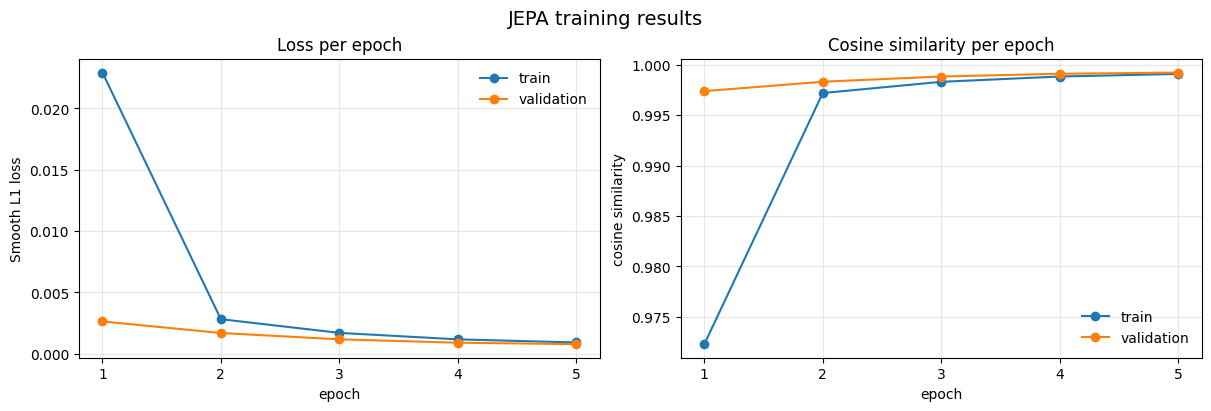

final epoch 5 | train loss 0.0009, val loss 0.0008 | train cosine 0.9991, val cosine 0.9992


In [61]:
history = result.get("history", [])
if not history:
    raise ValueError("result['history'] is empty; run train_jepa before plotting")

epochs = [row["epoch"] for row in history]
train_loss = [row["train_loss"] for row in history]
val_loss = [row["val_loss"] for row in history]
train_cosine = [row["train_cosine"] for row in history]
val_cosine = [row["val_cosine"] for row in history]

fig, (loss_ax, cosine_ax) = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

loss_ax.plot(epochs, train_loss, "o-", label="train")
loss_ax.plot(epochs, val_loss, "o-", label="validation")
loss_ax.set_title("Loss per epoch")
loss_ax.set_ylabel("Smooth L1 loss")

cosine_ax.plot(epochs, train_cosine, "o-", label="train")
cosine_ax.plot(epochs, val_cosine, "o-", label="validation")
cosine_ax.set_title("Cosine similarity per epoch")
cosine_ax.set_ylabel("cosine similarity")

for ax in (loss_ax, cosine_ax):
    ax.set_xlabel("epoch")
    ax.set_xticks(epochs)
    ax.grid(True, alpha=0.3)
    ax.legend(frameon=False)

fig.suptitle("JEPA training results", fontsize=14)
plt.show()

last = history[-1]
print(
    f"final epoch {last['epoch']} | "
    f"train loss {last['train_loss']:.4f}, val loss {last['val_loss']:.4f} | "
    f"train cosine {last['train_cosine']:.4f}, val cosine {last['val_cosine']:.4f}"
)